## loading data

In [1]:
import sys
sys.path.append("../")

from models_training.train_conversion_model import (
    create_spark,
    load_data,
    split_data, 
    apply_oversampling,
    model_pipeline,
    evaluate_model,
    roc_curve_model
)

In [2]:
# creer spark
spark = create_spark()

26/03/24 00:32:11 WARN Utils: Your hostname, nouhayla-HP-EliteBook-835-G7-Notebook-PC resolves to a loopback address: 127.0.1.1; using 192.168.96.226 instead (on interface wlp1s0)
26/03/24 00:32:11 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/24 00:32:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/24 00:32:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
# load new data
df = load_data(spark, "../data/silver/segment_data")
df.show()

+----------+----+------+--------+---------------+-------------+------------------+--------------------+-------------+------------------+------------------+------------+----------+-----------+-----------------+-------------+-------------------+---------------+----------+---------+-------------------+
|CustomerID| Age|Gender|  Income|CampaignChannel| CampaignType|           AdSpend|    ClickThroughRate|WebsiteVisits|     PagesPerVisit|        TimeOnSite|SocialShares|EmailOpens|EmailClicks|PreviousPurchases|LoyaltyPoints|AdvertisingPlatform|AdvertisingTool|Conversion|SegmentID|        SegmentName|
+----------+----+------+--------+---------------+-------------+------------------+--------------------+-------------+------------------+------------------+------------+----------+-----------+-----------------+-------------+-------------------+---------------+----------+---------+-------------------+
|      8000|56.0|Female|136912.0|   Social Media|    Awareness| 6497.870068417766| 0.043918510735

In [4]:
df.dtypes

[('CustomerID', 'string'),
 ('Age', 'double'),
 ('Gender', 'string'),
 ('Income', 'double'),
 ('CampaignChannel', 'string'),
 ('CampaignType', 'string'),
 ('AdSpend', 'double'),
 ('ClickThroughRate', 'double'),
 ('WebsiteVisits', 'double'),
 ('PagesPerVisit', 'double'),
 ('TimeOnSite', 'double'),
 ('SocialShares', 'double'),
 ('EmailOpens', 'double'),
 ('EmailClicks', 'double'),
 ('PreviousPurchases', 'double'),
 ('LoyaltyPoints', 'double'),
 ('AdvertisingPlatform', 'string'),
 ('AdvertisingTool', 'string'),
 ('Conversion', 'string'),
 ('SegmentID', 'int'),
 ('SegmentName', 'string')]

## l'impact des features sur la cible

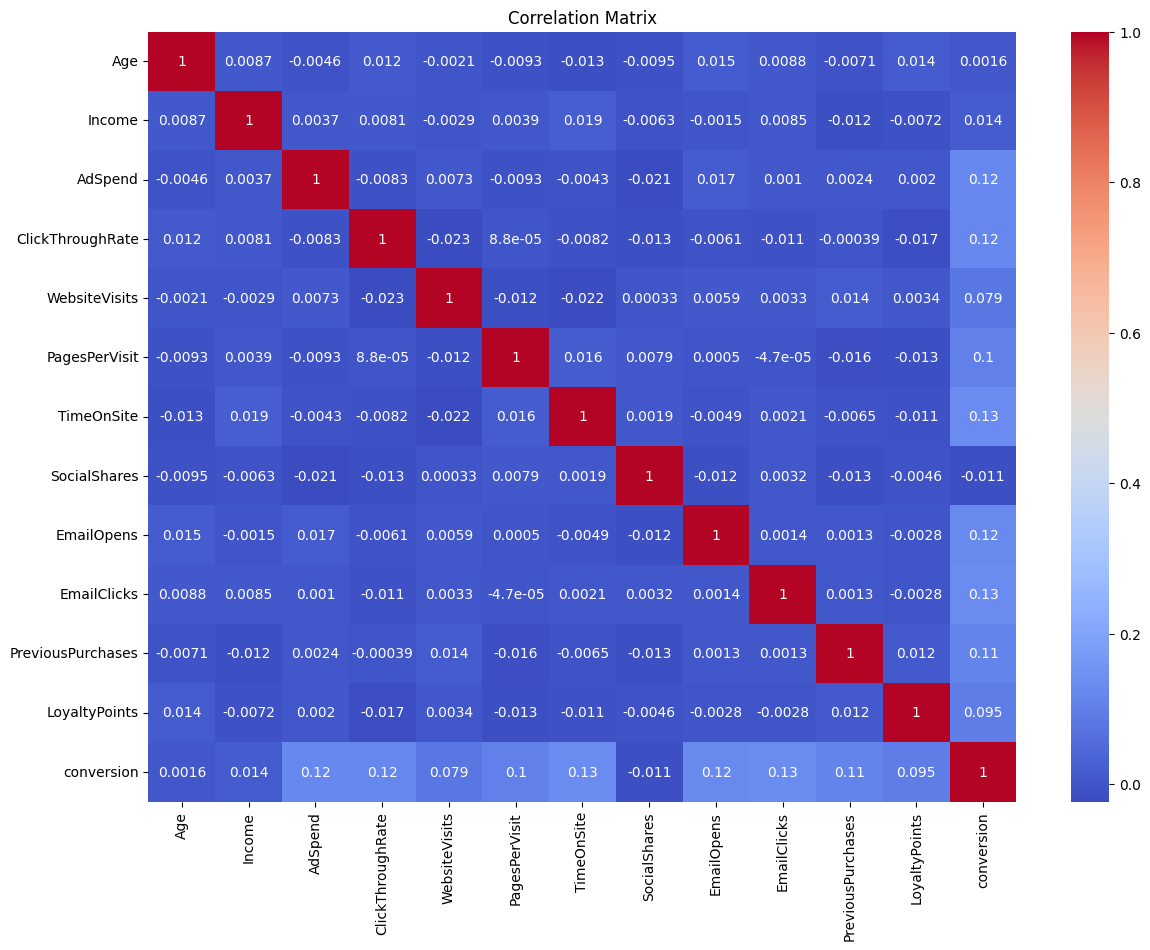

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col

# Colonnes numeriques
numeric_columns = [
    "Age",
    "Income",
    "AdSpend",
    "ClickThroughRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "SocialShares",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints",
    "conversion"
]

# convertir en double
for c in numeric_columns:
    df = df.withColumn(c, col(c).cast("double"))

# selectionner les colonnes
df_numeric = df.select(numeric_columns)

# convertir Spark to Pandas
pdf = df_numeric.toPandas()

# matrice de correlation
corr_matrix = pdf.corr()

# visualisation
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

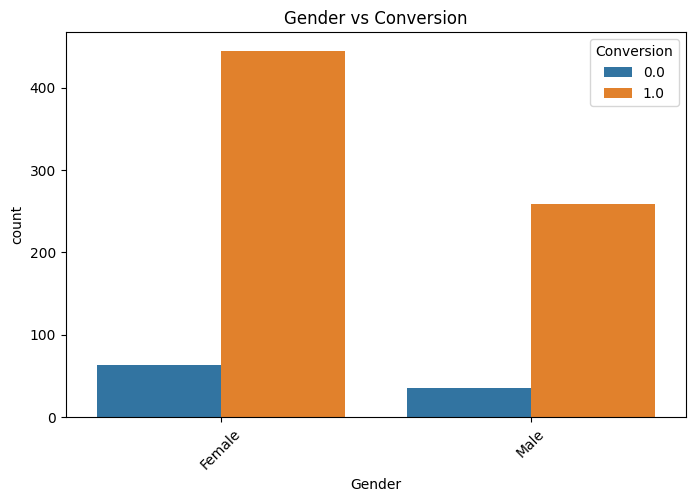

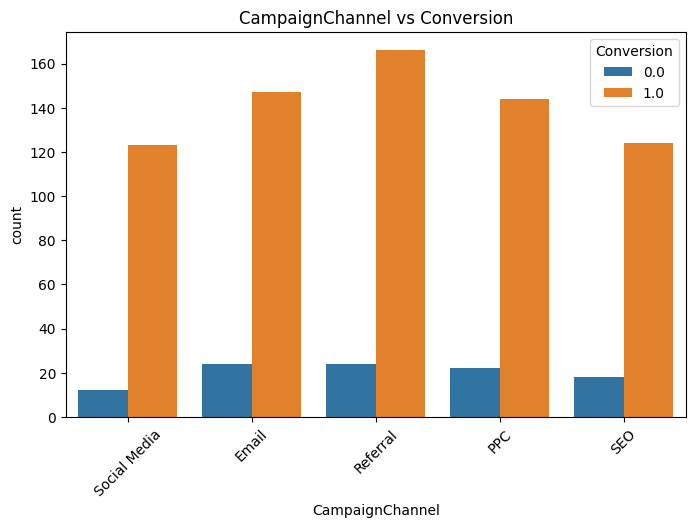

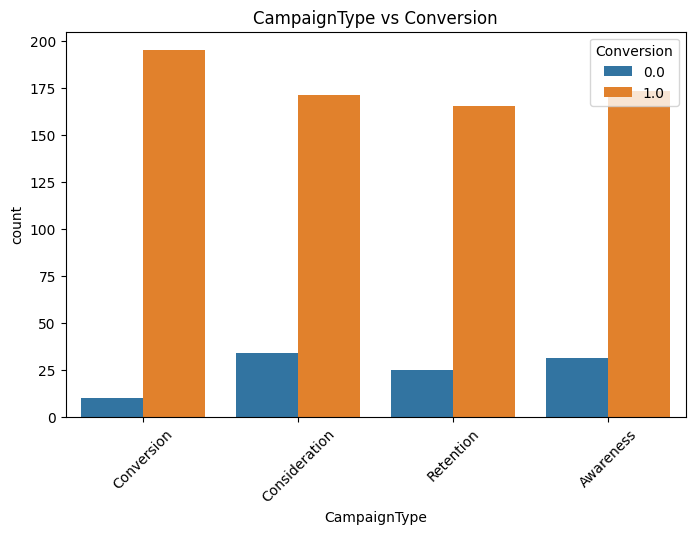

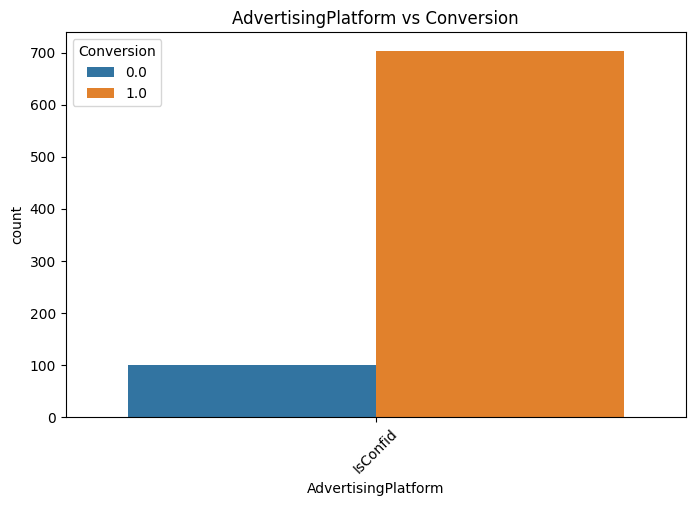

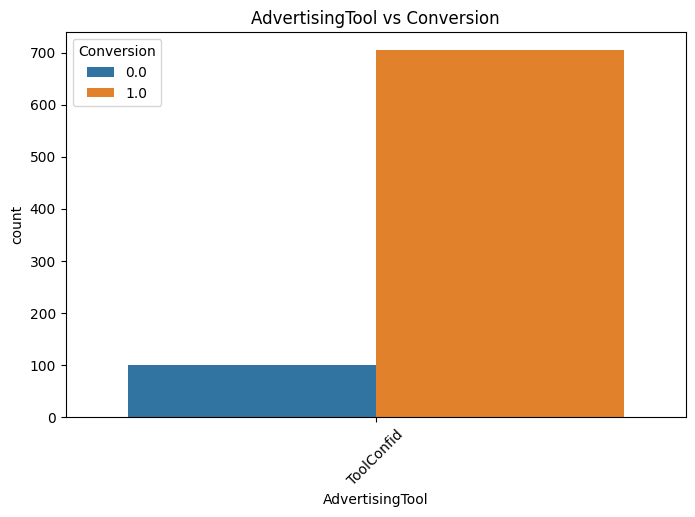

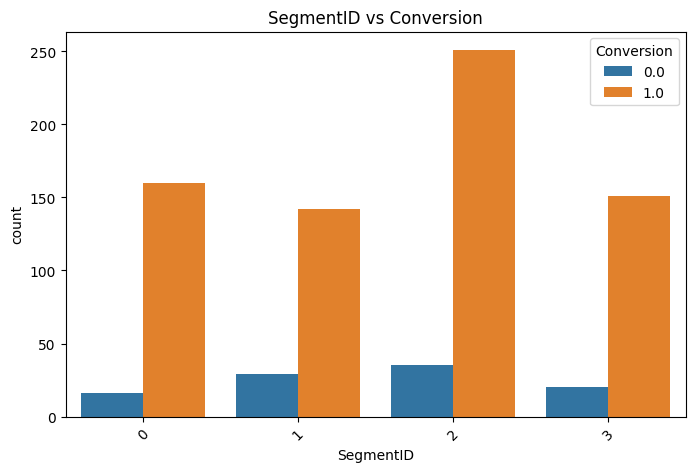

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

categorical_columns = [
    "Gender",
    "CampaignChannel",
    "CampaignType",
    "AdvertisingPlatform",
    "AdvertisingTool",
    'SegmentID'
]

# Sample Spark dataframe

sampled_df = df.select(categorical_columns + ["Conversion"]).sample(False, 0.1) .toPandas()
# print(sampled_df.dtypes)
for col in categorical_columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=sampled_df,
        x=col,
        hue="Conversion"
    )

    plt.xticks(rotation=45)

    plt.title(f"{col} vs Conversion")

    plt.show()

In [7]:
df = df.drop(
    "CustomerID",
    "Age",
    "Income",
    "WebsiteVisits",
    "SocialShares",
    "SegmentID"
)


In [8]:
df.columns

['Gender',
 'CampaignChannel',
 'CampaignType',
 'AdSpend',
 'ClickThroughRate',
 'PagesPerVisit',
 'TimeOnSite',
 'EmailOpens',
 'EmailClicks',
 'PreviousPurchases',
 'LoyaltyPoints',
 'AdvertisingPlatform',
 'AdvertisingTool',
 'conversion',
 'SegmentName']

## l'equilibre du data

In [9]:
df.groupBy("Conversion").count().show()

+----------+-----+
|Conversion|count|
+----------+-----+
|       0.0|  988|
|       1.0| 7012|
+----------+-----+



In [10]:
from pyspark.sql.functions import col

total = df.count()

df.groupBy("Conversion") \
  .count() \
  .withColumn("percentage", col("count")/total*100) \
  .show()

+----------+-----+-----------------+
|Conversion|count|       percentage|
+----------+-----+-----------------+
|       0.0|  988|            12.35|
|       1.0| 7012|87.64999999999999|
+----------+-----+-----------------+



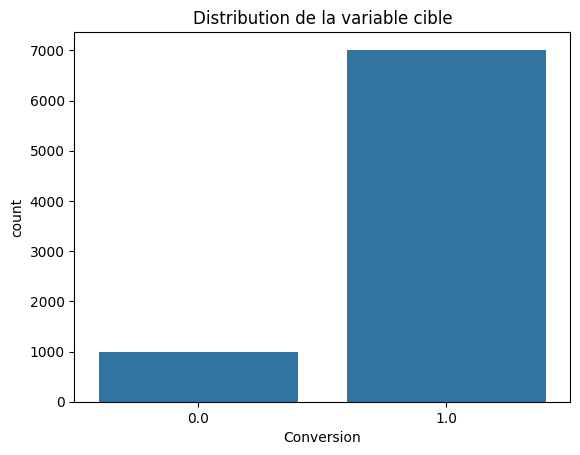

In [11]:
pdf = df.select("Conversion").toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=pdf, x="Conversion")
plt.title("Distribution de la variable cible")
plt.show()

## outliers

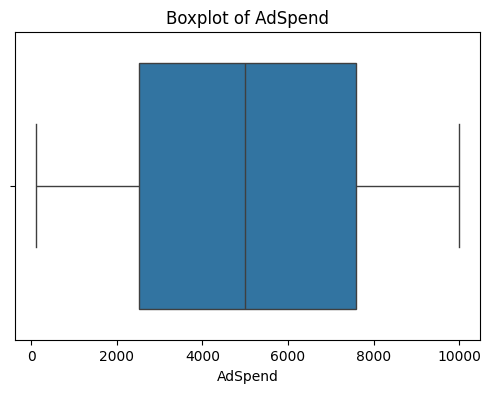

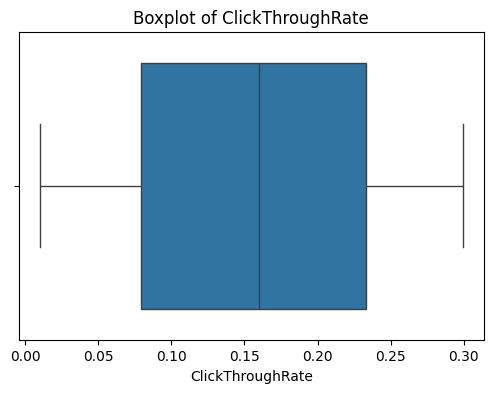

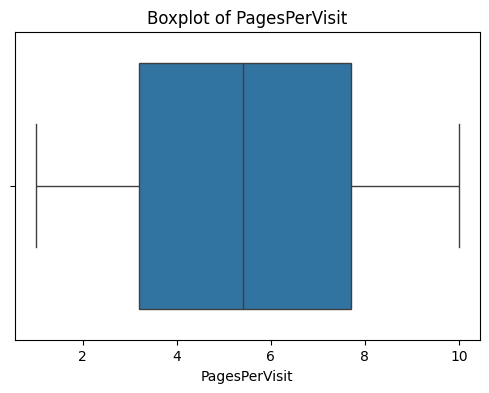

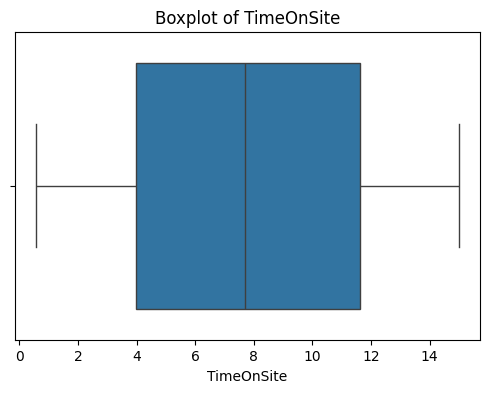

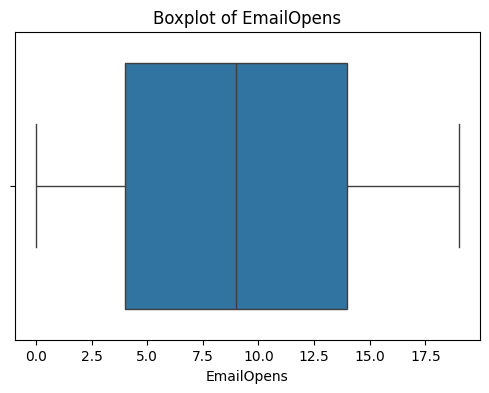

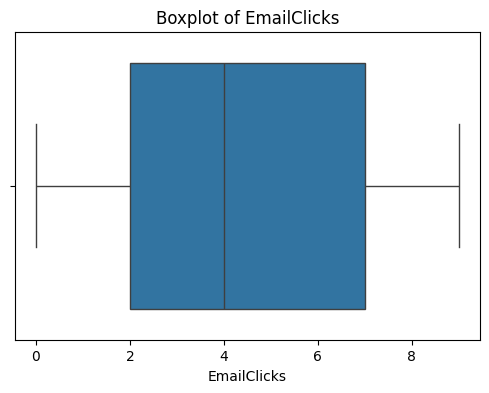

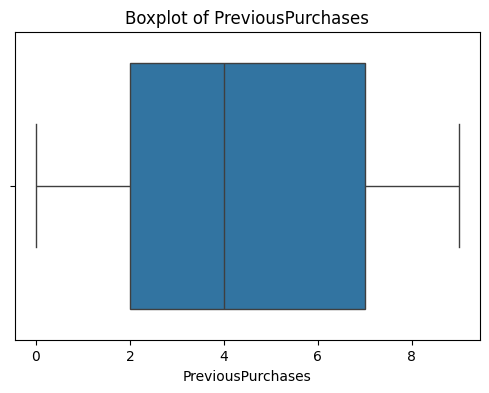

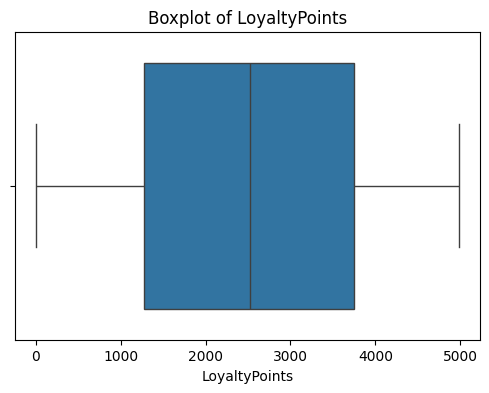

In [12]:
numeric_columns = [
    "AdSpend",
    "ClickThroughRate",
    "PagesPerVisit",
    "TimeOnSite",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints"
]


 

pdf = df.select(*numeric_columns).sample(False, 0.1).toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=pdf[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## data de l'antrainement

In [13]:
# categorical_columns
cat_columns = [
    "Gender",
    "CampaignChannel",
    "CampaignType",
    "AdvertisingPlatform",
    "AdvertisingTool",
    'SegmentName'
]


# numeric_columns
num_columns = [
    "AdSpend",
    "ClickThroughRate",
    "PagesPerVisit",
    "TimeOnSite",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints"
]


## Modelisation

In [14]:
train_df, test_df = split_data(df, test_size=0.2)
train_df = apply_oversampling(train_df)

+----------+-----+
|conversion|count|
+----------+-----+
|       0.0| 5746|
|       1.0| 5667|
+----------+-----+



In [15]:
from pyspark.ml.classification import LogisticRegression

# logistic regression pipeline
pipeline_LR = model_pipeline(
    num_columns,
    cat_columns,
    LogisticRegression(
        featuresCol="features",
        labelCol="conversion"
    )
)

In [16]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# logistic regression  GridSearch
lr_model = pipeline_LR.getStages()[-1]

paramGrid_LR = (
    ParamGridBuilder()
    .addGrid(lr_model.regParam, [0.01, 0.1, 1])
    .addGrid(lr_model.elasticNetParam, [0])
    .build()
)

evaluator = BinaryClassificationEvaluator(
    labelCol="conversion"
)

cv_LR = CrossValidator(
    estimator=pipeline_LR,
    estimatorParamMaps=paramGrid_LR,
    evaluator=evaluator,
    numFolds=3
)

In [17]:
# training logistic regression
best_LR = cv_LR.fit(train_df)

26/03/24 00:32:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/24 00:32:27 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
26/03/24 00:32:28 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


In [18]:
# evaluation metrics
metrics = evaluate_model(best_LR, test_df)

print(metrics)

{'accuracy': 0.7066142763588736, 'precision': 0.8627109991971209, 'recall': 0.7066142763588736, 'f1_score': 0.7562366126676623, 'auc': 0.7741370154009564}


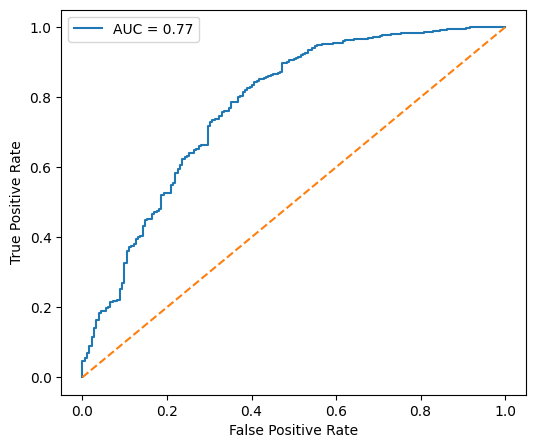

In [19]:
import matplotlib.pyplot as plt

fpr, tpr, roc_auc = roc_curve_model(best_LR, test_df)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

In [20]:
from pyspark.ml.classification import RandomForestClassifier

# random forest pipeline
pipeline_RF = model_pipeline(
    num_columns,
    cat_columns,
    RandomForestClassifier(
        featuresCol="features",
        labelCol="conversion"
    )
)

In [21]:
# random forest GridSearch
rf_model = pipeline_RF.getStages()[-1]

paramGrid_RF = (
    ParamGridBuilder()
    .addGrid(rf_model.numTrees, [50, 100])
    .addGrid(rf_model.maxDepth, [5, 10])
    .build()
)

cv_RF = CrossValidator(
    estimator=pipeline_RF,
    estimatorParamMaps=paramGrid_RF,
    evaluator=evaluator,
    numFolds=3
)

In [22]:
# training random forest
best_RF = cv_RF.fit(train_df)

26/03/24 00:32:58 WARN DAGScheduler: Broadcasting large task binary with size 1648.0 KiB
26/03/24 00:32:59 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/03/24 00:32:59 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
26/03/24 00:33:00 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/03/24 00:33:05 WARN DAGScheduler: Broadcasting large task binary with size 1027.0 KiB
26/03/24 00:33:06 WARN DAGScheduler: Broadcasting large task binary with size 1803.3 KiB
26/03/24 00:33:06 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/03/24 00:33:07 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB
26/03/24 00:33:09 WARN DAGScheduler: Broadcasting large task binary with size 7.0 MiB
26/03/24 00:33:10 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/03/24 00:33:15 WARN DAGScheduler: Broadcasting large task binary with size 1654.6 KiB
26/03/24 00:33:16 WARN DAGScheduler: Broad

In [23]:
# Evaluation metrics
metrics = evaluate_model(best_RF, test_df)

print(metrics)

26/03/24 00:33:54 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/03/24 00:33:54 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
26/03/24 00:33:55 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
26/03/24 00:33:56 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
26/03/24 00:33:56 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB


{'accuracy': 0.8958742632612967, 'precision': 0.8908864451584508, 'recall': 0.8958742632612967, 'f1_score': 0.8930900310938166, 'auc': 0.8099391315004701}


26/03/24 00:33:57 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB


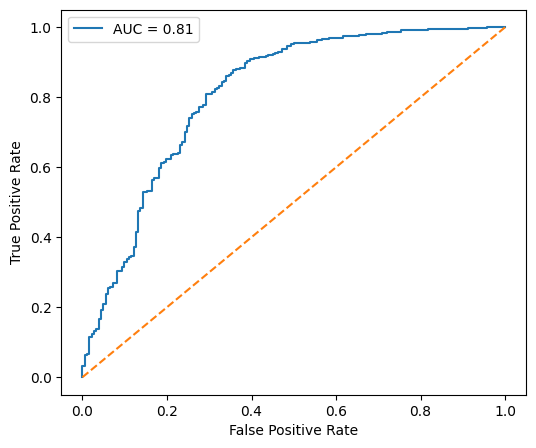

In [24]:
import matplotlib.pyplot as plt

fpr, tpr, roc_auc = roc_curve_model(best_RF, test_df)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

In [25]:
best_RF.write().overwrite().save("models")
print("conversion model trained successfully")

conversion model trained successfully
